# 📈 Stock Prediction: AMD & NVIDIA
Using LSTM, GRU, and GARCH

Date Range: 01-01-2024 to 01-02-2026

In [2]:
!pip install arch

   ---------------------------------------- 0.0/929.7 kB ? eta -:--:--
   ---------------------------------------- 929.7/929.7 kB 11.0 MB/s  0:00:00


In [3]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import math

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, GRU

from arch import arch_model


## 📊 Load Data from yfinance

In [4]:
tickers = ['AMD', 'NVDA']
start_date = '2024-01-01'
end_date = '2026-02-01'

data = yf.download(tickers, start=start_date, end=end_date)['Close']
data = data.dropna()

data.head()


[*********************100%***********************]  2 of 2 completed


Ticker,AMD,NVDA
Date,,
2024-01-02,138.580002,48.138573
2024-01-03,135.320007,47.539936
2024-01-04,136.009995,47.968681
2024-01-05,138.580002,49.067009
2024-01-08,146.179993,52.221077


## 📉 Price Visualization

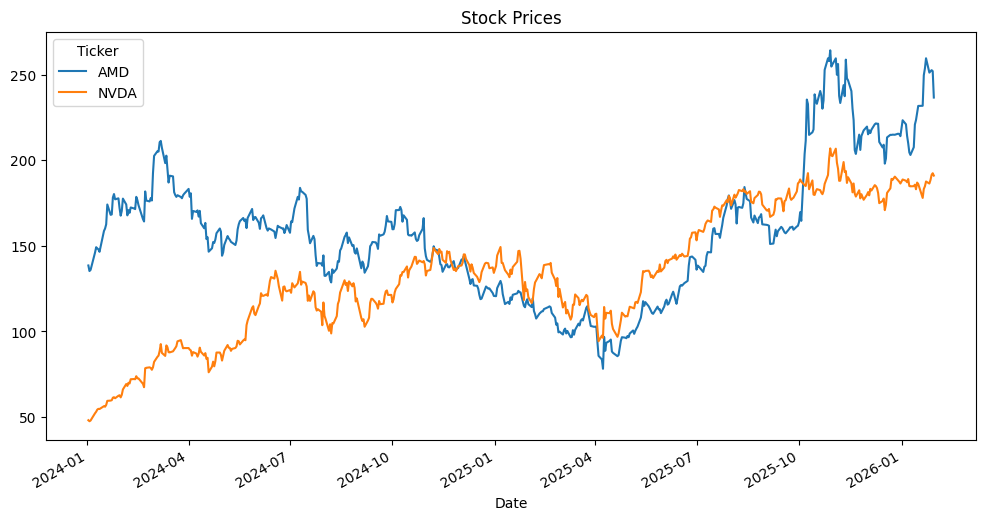

In [5]:
data.plot(figsize=(12,6))
plt.title("Stock Prices")
plt.show()


## ⚙️ Data Preprocessing

In [6]:
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(data)

def create_dataset(dataset, time_step=30):
    X, y = [], []
    for i in range(len(dataset)-time_step-1):
        X.append(dataset[i:(i+time_step)])
        y.append(dataset[i+time_step])
    return np.array(X), np.array(y)

time_step = 30
X, y = create_dataset(scaled_data, time_step)


## ✂️ Train-Test Split

In [7]:
train_size = int(len(X)*0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]


## 🧠 LSTM Model

In [8]:
model_lstm = Sequential([
    LSTM(50, return_sequences=True, input_shape=(time_step, 2)),
    LSTM(50),
    Dense(2)
])

model_lstm.compile(optimizer='adam', loss='mse')
model_lstm.fit(X_train, y_train, epochs=5, batch_size=32, verbose=1)

lstm_pred = model_lstm.predict(X_test)


C:\Users\LENOVO\miniconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.0517
Epoch 2/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0115
Epoch 3/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0053
Epoch 4/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0040
Epoch 5/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0037
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step


## 🔁 GRU Model

In [9]:
model_gru = Sequential([
    GRU(50, return_sequences=True, input_shape=(time_step, 2)),
    GRU(50),
    Dense(2)
])

model_gru.compile(optimizer='adam', loss='mse')
model_gru.fit(X_train, y_train, epochs=5, batch_size=32, verbose=1)

gru_pred = model_gru.predict(X_test)


Epoch 1/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 0.0554
Epoch 2/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0132
Epoch 3/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0066
Epoch 4/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0032
Epoch 5/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0021
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 144ms/step


## 📊 GARCH Model (Volatility)

In [10]:
returns = data.pct_change().dropna()

garch_results = {}

for col in returns.columns:
    model = arch_model(returns[col]*100, vol='Garch', p=1, q=1)
    res = model.fit(disp='off')
    garch_results[col] = res

garch_results


{'AMD':                      Constant Mean - GARCH Model Results                      
 Dep. Variable:                    AMD   R-squared:                       0.000
 Mean Model:             Constant Mean   Adj. R-squared:                  0.000
 Vol Model:                      GARCH   Log-Likelihood:               -1369.98
 Distribution:                  Normal   AIC:                           2747.96
 Method:            Maximum Likelihood   BIC:                           2764.98
                                         No. Observations:                  521
 Date:                Thu, Apr 02 2026   Df Residuals:                      520
 Time:                        11:44:03   Df Model:                            1
                                Mean Model                               
                  coef    std err          t      P>|t|  95.0% Conf. Int.
 ------------------------------------------------------------------------
 mu             0.2118      0.171      1.239      0

## 📏 Model Evaluation

In [11]:
def rmse(y_true, y_pred):
    return math.sqrt(mean_squared_error(y_true, y_pred))

print("LSTM RMSE:", rmse(y_test, lstm_pred))
print("GRU RMSE:", rmse(y_test, gru_pred))


LSTM RMSE: 0.15179681143803367
GRU RMSE: 0.10430401995557413


## 🔧 Hyperparameter Insights

Try changing:
- epochs (5 → 20)
- batch size (32 → 64)
- units (50 → 100)

Observe impact on RMSE.